- There are 10 thousand files representing systems with a different configuration of m1 [Mo], m2 [Mo], rhosp [Mo/pc^2], gsp. 
- Each file has a set of 200 points in frequency [Hz], and dephasing [rad]. 


In [27]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import torch
import glob

In [44]:
data = glob.glob('data/dephasing_sample_*.csv')

In [45]:
data

['data/dephasing_sample_6112.csv',
 'data/dephasing_sample_9221.csv',
 'data/dephasing_sample_4705.csv',
 'data/dephasing_sample_2374.csv',
 'data/dephasing_sample_2412.csv',
 'data/dephasing_sample_4063.csv',
 'data/dephasing_sample_8659.csv',
 'data/dephasing_sample_8881.csv',
 'data/dephasing_sample_6674.csv',
 'data/dephasing_sample_9547.csv',
 'data/dephasing_sample_8895.csv',
 'data/dephasing_sample_6660.csv',
 'data/dephasing_sample_9553.csv',
 'data/dephasing_sample_5369.csv',
 'data/dephasing_sample_2406.csv',
 'data/dephasing_sample_3718.csv',
 'data/dephasing_sample_4077.csv',
 'data/dephasing_sample_4711.csv',
 'data/dephasing_sample_2360.csv',
 'data/dephasing_sample_6106.csv',
 'data/dephasing_sample_9235.csv',
 'data/dephasing_sample_1669.csv',
 'data/dephasing_sample_7218.csv',
 'data/dephasing_sample_4739.csv',
 'data/dephasing_sample_3056.csv',
 'data/dephasing_sample_2348.csv',
 'data/dephasing_sample_5427.csv',
 'data/dephasing_sample_489.csv',
 'data/dephasing_samp

In [46]:
sample_files = sorted(glob.glob('data/dephasing_sample_*.csv'),
                      key=lambda f: int(f.split('_')[-1].split('.')[0]))

In [48]:
len(sample_files)

10000

In [49]:
sample_files = sorted(glob.glob('data/dephasing_sample_*.csv'),
                      key=lambda f: int(f.split('_')[-1].split('.')[0])) # sort by last number of filenames

data_array = []
params = []

for sample in sample_files:
    # for metadata 
    with open(sample) as f:
        meta_params = f.readline() # to get m1, m2, rhosp, gsp
    param_dict = {}
    for item in meta_params.strip().split(', '):
        parts = item.split('=')
        key = parts[0]
        value = np.float64(parts[1])   # convert for later maybe
        param_dict[key] = value
    # read data
    read_data = np.loadtxt(sample, delimiter=',', skiprows=2)
    
    data_array.append(read_data)
    params.append(param_dict)

data_array = np.array(data_array)  # shape: (n_files, n_rows, 2)

In [50]:
data_array.shape

(10000, 200, 2)

In [51]:
len(params)

10000

Text(0, 0.5, '$\\Delta \\phi$')

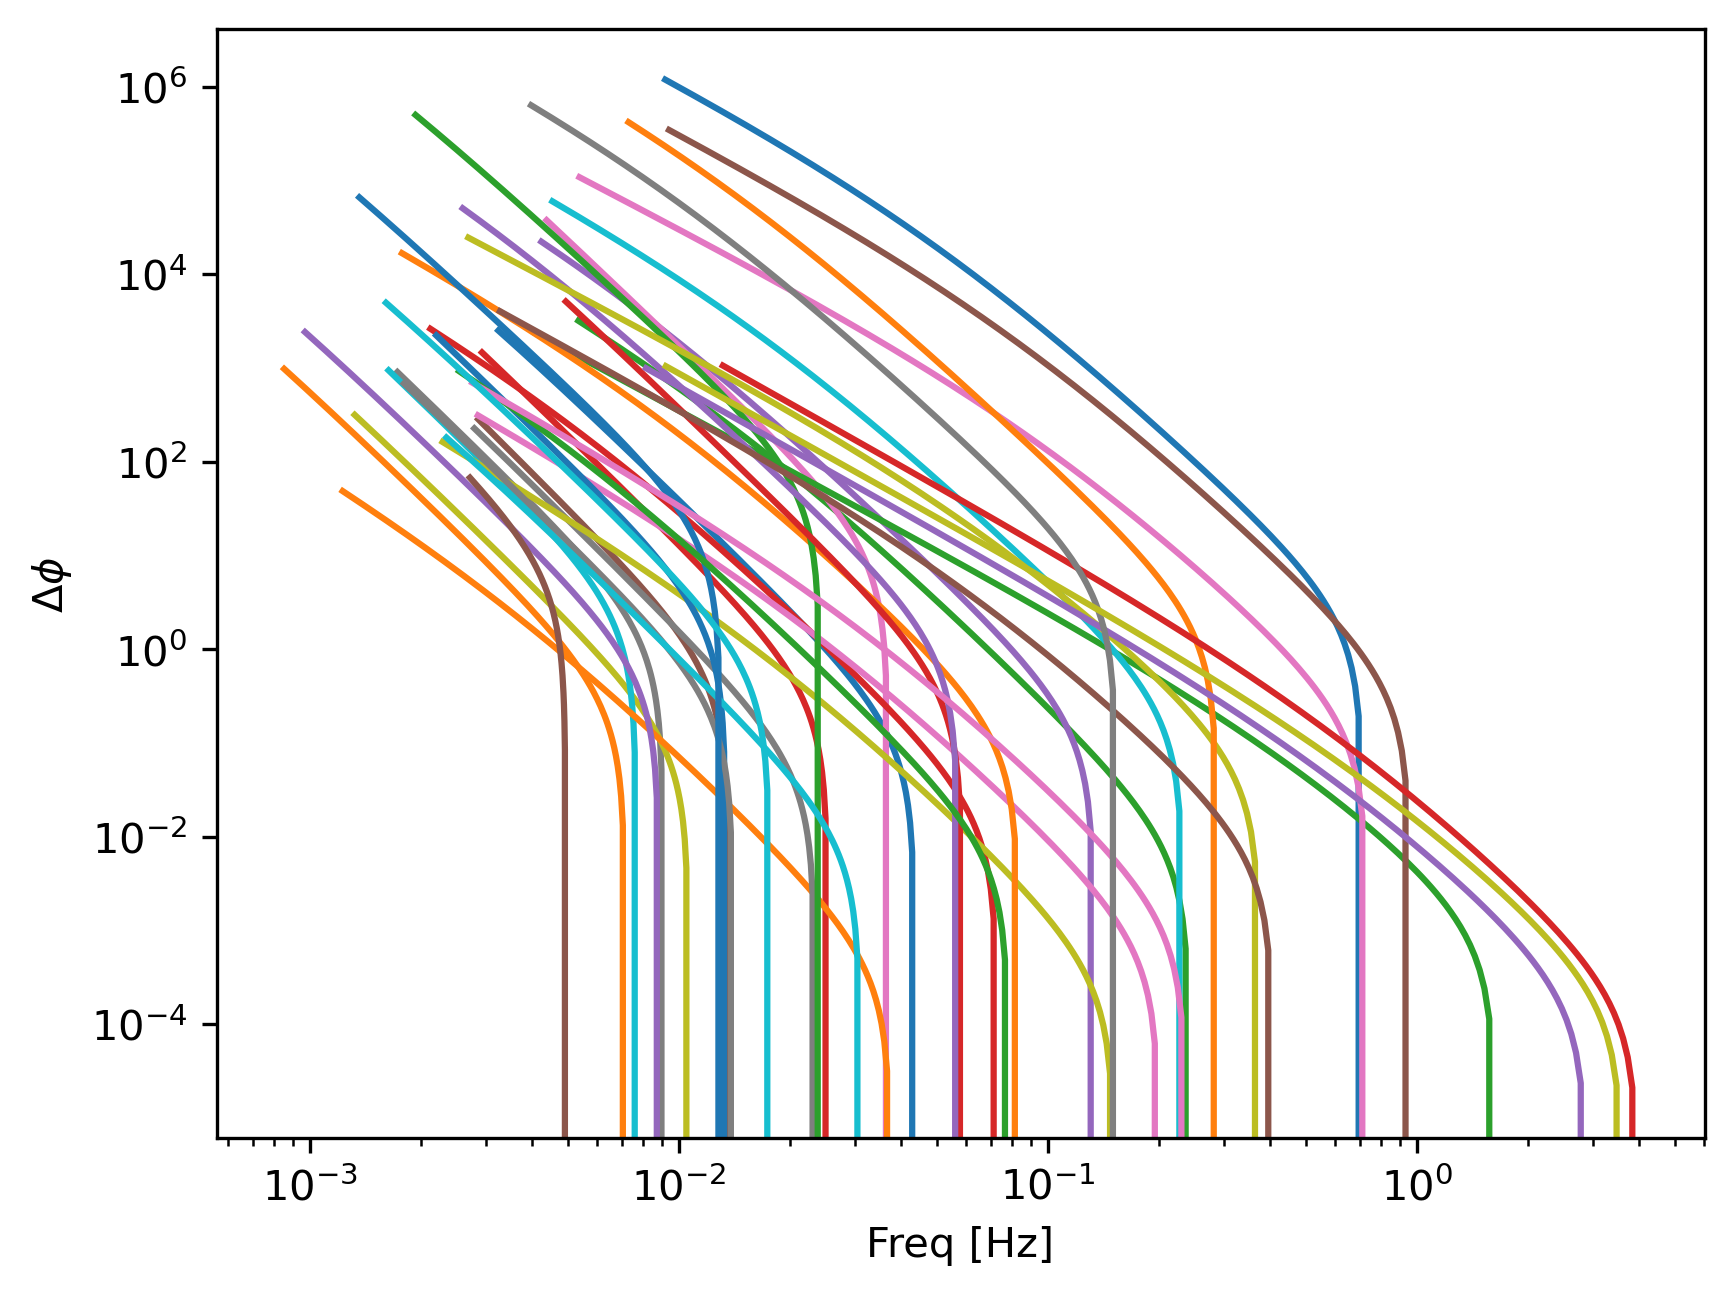

In [60]:
plt.figure(dpi=300)
for i in range(40): 
    plt.loglog(data_array[i,:,0], data_array[i,:,1])

plt.xlabel('Freq [Hz]')
plt.ylabel('$\Delta \phi$')

In [38]:
params[0]            # look at the metadata for the first file


{'m1': 101268.01, 'm2': 8.197, 'gsp': 2.138, 'rhosp': 2904.897}

In [39]:
params[0]['m1']      # look at a specific value

101268.01

In [22]:
params5, sample5 = dephasing_sample_reader('data/dephasing_sample_5.csv')

In [ ]:
for i in range(10000)

{'m1': '33114.307', ' m2': '8.440', ' gsp': '2.306', ' rhosp': '36.793'}

In [24]:
import glob

In [26]:
glob.glob?

Signature:
glob.glob(
    pathname,
    *,
    root_dir=None,
    dir_fd=None,
    recursive=False,
    include_hidden=False,
)
Docstring:
Return a list of paths matching a pathname pattern.

The pattern may contain simple shell-style wildcards a la
fnmatch. Unlike fnmatch, filenames starting with a
dot are special cases that are not matched by '*' and '?'
patterns by default.

If `include_hidden` is true, the patterns '*', '?', '**'  will match hidden
directories.

If `recursive` is true, the pattern '**' will match any files and
zero or more directories and subdirectories.
File:      ~/anaconda3/lib/python3.11/glob.py
Type:      function

In [8]:
sample1 = pd.read_csv('data/dephasing_sample_1.csv', skiprows=1)
#sample50 = pd.read_csv('data/dephasing_sample_50.csv')

In [9]:
sample1

,fGW[Hz],dPh[rad]
0,0.003242,2517.620000
1,0.003285,2405.090000
2,0.003328,2297.410000
3,0.003371,2194.370000
4,0.003416,2095.790000
...,...,...
195,0.041215,0.029742
196,0.041756,0.021730
197,0.042304,0.014116
198,0.042859,0.006879


In [18]:
sample5 = pd.read_csv('data/dephasing_sample_5.csv', skiprows=0)
sample5.loc[0]

m1=33114.307      fGW[Hz]
 m2=8.440        dPh[rad]
 gsp=2.306            NaN
 rhosp=36.793         NaN
Name: 0, dtype: object

In [19]:
sample5.index

RangeIndex(start=0, stop=201, step=1)

In [5]:
sample50

,m1=428666.366,m2=55.847,gsp=2.022,rhosp=30.312
0,fGW[Hz],dPh[rad],NaN,NaN
1,1.10068e-03,3.03026e+01,NaN,NaN
2,1.11310e-03,2.90935e+01,NaN,NaN
3,1.12565e-03,2.79311e+01,NaN,NaN
4,1.13835e-03,2.68137e+01,NaN,NaN
...,...,...,...,...
196,9.80808e-03,1.03218e-03,NaN,NaN
197,9.91871e-03,7.56664e-04,NaN,NaN
198,1.00306e-02,4.93137e-04,NaN,NaN
199,1.01437e-02,2.41082e-04,NaN,NaN
